In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
from src.models.model import LitS4Model
from src.data.data import LitDataModule
from src.utils.plotting import *
import torch
from torch.utils.data import DataLoader
device = 'cuda' if torch.cuda.is_available() else 'cpu'
import tqdm
import numpy as np
import yaml
from scipy import signal

/n/holystore01/LABS/iaifi_lab/Users/creissel/miniforge/envs/ssm/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
path = '/n/home03/creissel/neutrino_project/runs/longtracks_cutoff8192_MSELoss_currentbest/lightning_logs/si7ugqep'
CHECKPOINT = os.path.join(path, 'checkpoints/last.ckpt')
image_folder = os.path.join(path, 'results')

In [5]:
! mkdir "{image_folder}"

mkdir: cannot create directory ‘/n/home03/creissel/neutrino_project/runs/longtracks_cutoff8192_MSELoss_currentbest/lightning_logs/si7ugqep/results’: File exists


In [7]:
model = LitS4Model.load_from_checkpoint(CHECKPOINT)
model = model.to(device)
model = model.eval()

/n/holystore01/LABS/iaifi_lab/Users/creissel/miniforge/envs/ssm/lib/python3.10/site-packages/lightning/pytorch/utilities/parsing.py:209: Attribute 'encoder' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['encoder'])`.


In [8]:
dataset = LitDataModule.load_from_checkpoint(CHECKPOINT)

In [9]:
true = []
pred = []
meta = []

max_powers = []
summed_powers = []

for ts,fft,var,obs in dataset.test_dataloader():
    with torch.no_grad():
        pred.append(model(fft.to(device)).cpu().numpy())
        true.append(var.numpy())
        meta.append(obs.numpy())

/n/holystore01/LABS/iaifi_lab/Users/creissel/miniforge/envs/ssm/lib/python3.10/site-packages/torch/nn/functional.py:1381: UserWarning: dropout2d: Received a 3D input to dropout2d and assuming that channel-wise 1D dropout behavior is desired - input is interpreted as shape (N, C, L), where C is the channel dim. This behavior will change in a future release to interpret the input as one without a batch dimension, i.e. shape (C, H, W). To maintain the 1D channel-wise dropout behavior, please switch to using dropout1d instead.
  warnings.warn("dropout2d: Received a 3D input to dropout2d and assuming that channel-wise "


In [10]:
#true = np.concatenate(true)
#pred = np.concatenate(pred)

true = np.concatenate(true, axis=0)
pred = np.concatenate(pred, axis=0)
meta = np.concatenate(meta, axis=0)

In [11]:
# undo the normalization
pred_post = pred * dataset.stds + dataset.mu
true_post = true * dataset.stds + dataset.mu

/n/home03/creissel/neutrino_project/runs/longtracks_cutoff8192_MSELoss_currentbest/lightning_logs/si7ugqep/results


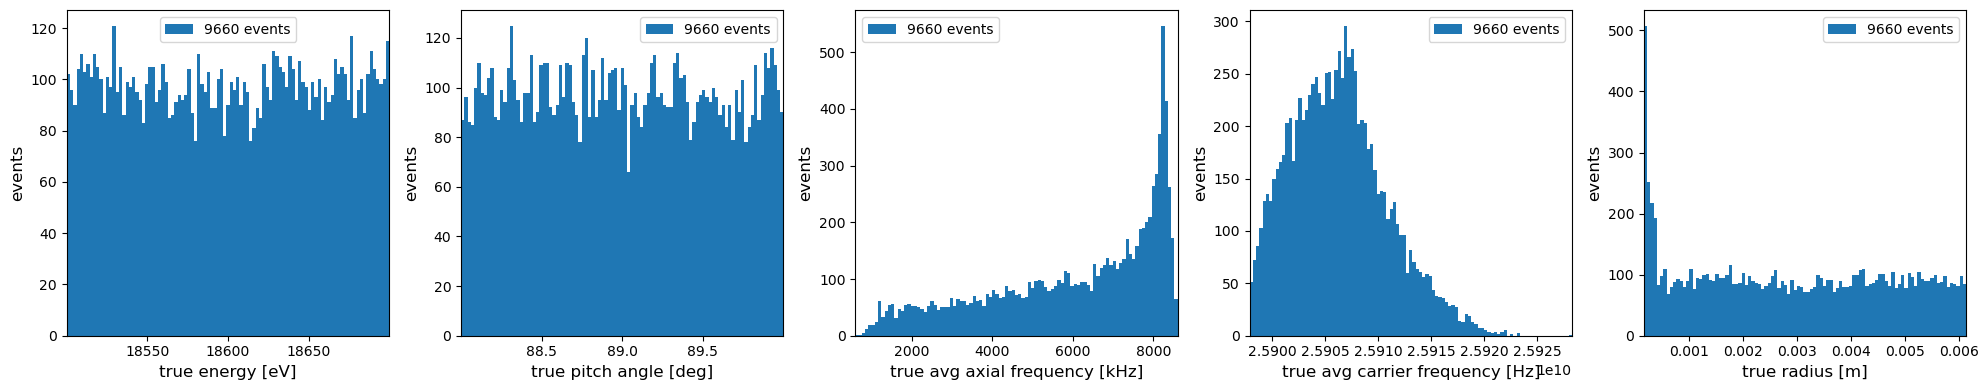

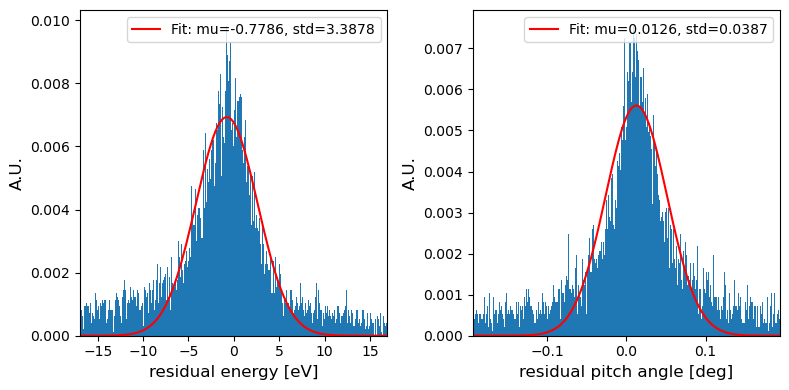

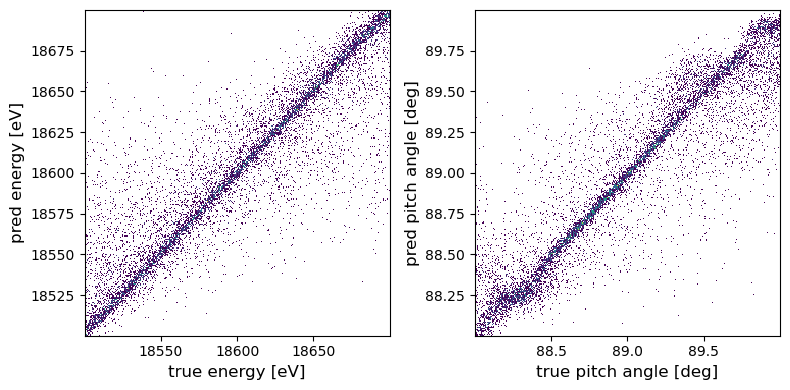

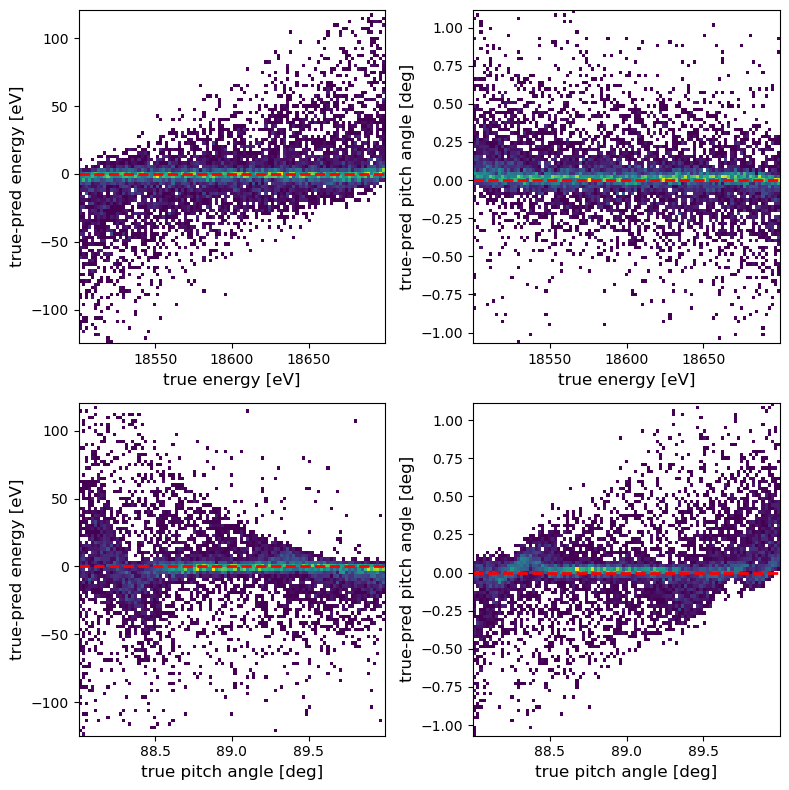

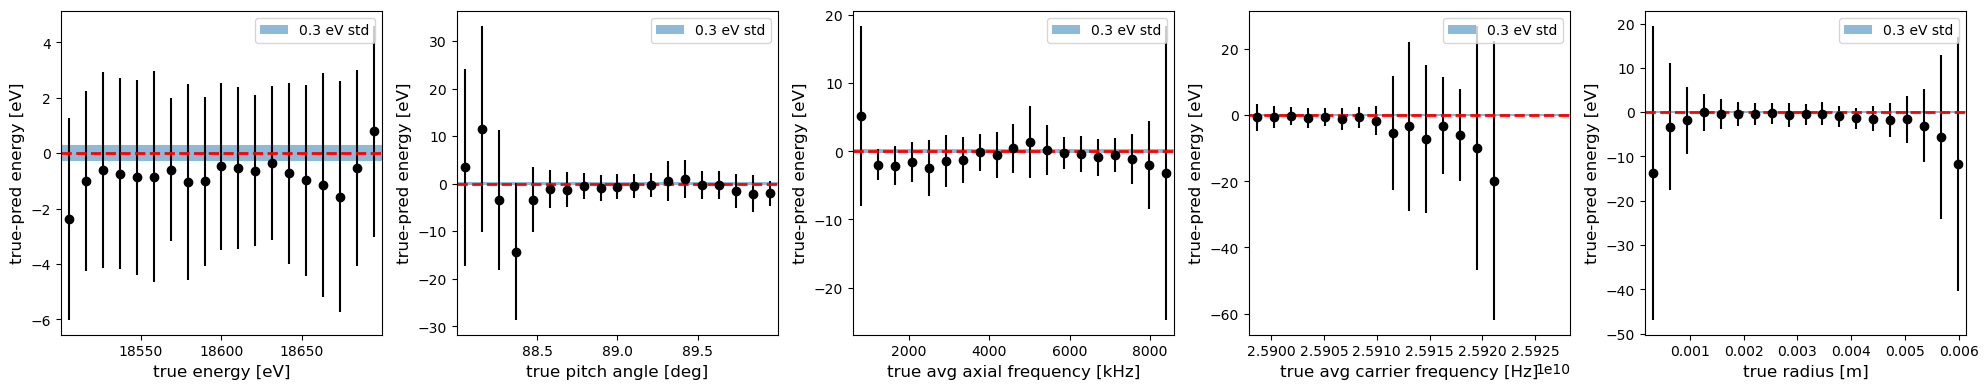

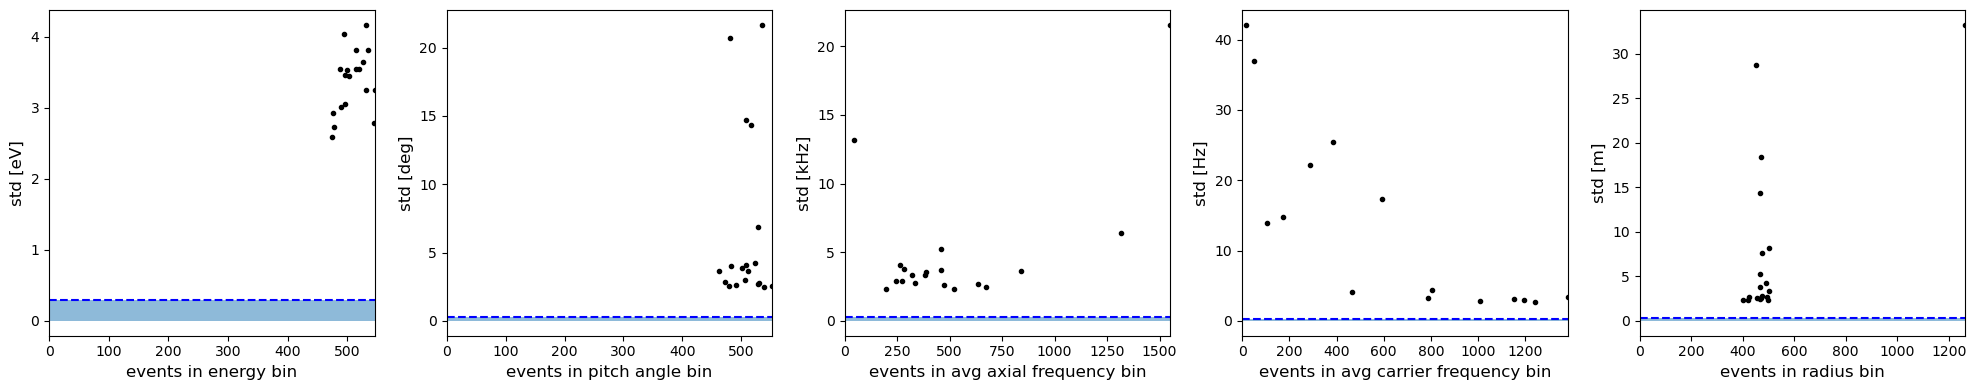

In [12]:
f = make_all_plots(dataset.variables, dataset.observables,true_post, pred_post, meta, folder=image_folder, savefigs=True)

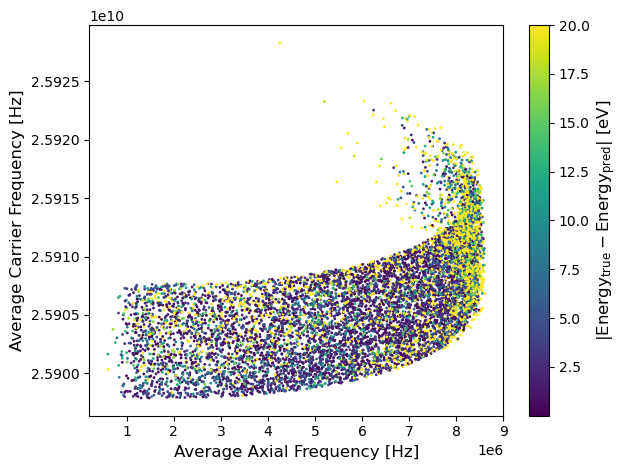

In [13]:
# true, pred: energy_eV, pitch_angle_deg
# meta: avg_axial_frequency_Hz, avg_carrier_frequency_Hz, radius_m

avg_axial_frequency_Hz = meta[:, 0]
avg_carrier_frequency_Hz = meta[:, 1]
true_energy = true_post[:, 0]
pred_energy = pred_post[:, 0]

fig, ax = plt.subplots()

sc = ax.scatter(
    avg_axial_frequency_Hz,
    avg_carrier_frequency_Hz,
    c=np.abs(true_energy - pred_energy),
    s=1,
    cmap='viridis', 
    vmax=20
)

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label(r"$|\text{Energy}_{\text{true}} - \text{Energy}_{\text{pred}}|$ [eV]")

plt.xlabel("Average Axial Frequency [Hz]")
plt.ylabel("Average Carrier Frequency [Hz]")

plt.tight_layout()
plt.show()
